In [42]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta

In [43]:
df = pd.read_csv('online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [44]:
#RFM = RECENCY, FREQUENCY, MONETARY VALUE

snapshot_date = df['InvoiceDate'].max() + timedelta(days = 1)

print(f"Data until : {df['InvoiceDate'].max()}")
print(f"Snapshot date: {snapshot_date}")

Data until : 2011-12-09 12:50:00
Snapshot date: 2011-12-10 12:50:00


In [45]:
# Calculate RFM for each customer

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: days since last purchase
    'InvoiceNo': 'nunique',  # Frequency: number of unique invoices
    'TotalPrice': 'sum'  # Monetary: total spent
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [46]:
print("RFM Statistics:")
print(rfm.describe())

RFM Statistics:
         CustomerID      Recency    Frequency       Monetary
count   4332.000000  4332.000000  4332.000000    4332.000000
mean   15300.269160    92.560480     4.256925    1836.342658
std     1721.114668    99.948771     7.630449    6694.003877
min    12347.000000     1.000000     1.000000       2.900000
25%    13813.750000    18.000000     1.000000     306.677500
50%    15299.500000    51.000000     2.000000     668.250000
75%    16778.250000   142.000000     5.000000    1632.272500
max    18287.000000   374.000000   209.000000  265989.860000


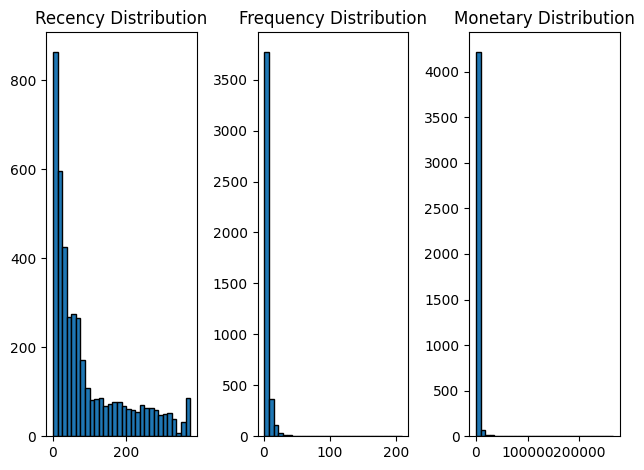

In [47]:
#check for outliers in Monetary
plt.figure()
plt.subplot(1, 3, 1)
plt.hist(rfm['Recency'], bins=30, edgecolor='black')
plt.title('Recency Distribution')

plt.subplot(1, 3,2 )
plt.hist(rfm['Frequency'], bins=30, edgecolor='black')
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
plt.hist(rfm['Monetary'], bins=30, edgecolor='black')
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [48]:
#remove extreme monetary outliers  for better segmentation
monetary_cap = rfm['Monetary'].quantile(0.99)
rfm_clean = rfm[rfm['Monetary'] <= monetary_cap].copy()

print(f"Remove {len(rfm) - len(rfm_clean)} outlier customers")
print(f"Working with {len(rfm_clean)} customers")

Remove 44 outlier customers
Working with 4288 customers


In [49]:
#create quartile for each metraic

rfm_clean['R_Quartile'] = pd.qcut(rfm_clean['Recency'], 4, labels=['4', '3', '2', '1'])
rfm_clean['F_Quartile'] = pd.qcut(rfm_clean['Frequency'].rank(method='first'), 4, labels=['1','2', '3', '4'])
rfm_clean['M_Quartile'] = pd.qcut(rfm_clean['Monetary'], 4, labels=['1', '2', '3', '4'])

In [50]:
#combine_scores

rfm_clean['RFM_Score'] = rfm_clean['R_Quartile'].astype(str) + \
                         rfm_clean['F_Quartile'].astype(str) + \
                         rfm_clean['M_Quartile'].astype(str)

# top customers
rfm_clean.sort_values('RFM_Score', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Quartile,F_Quartile,M_Quartile,RFM_Score
0,12347.0,2,7,4310.00,4,4,4,444
2933,16353.0,4,23,6675.71,4,4,4,444
693,13269.0,1,15,5346.23,4,4,4,444
2999,16440.0,8,5,3640.67,4,4,4,444
2990,16426.0,2,10,1908.25,4,4,4,444
2976,16407.0,13,10,2126.93,4,4,4,444
2970,16401.0,1,12,4098.32,4,4,4,444
2964,16393.0,2,13,3046.21,4,4,4,444
2939,16360.0,5,6,3512.53,4,4,4,444
2938,16359.0,7,9,1750.92,4,4,4,444


In [51]:
#product popularity
product_features = df.groupby('StockCode').agg({
    'Description': 'first',
    'Quantity': ['sum', 'mean'],
    'TotalPrice': ['sum', 'mean'],
    'InvoiceNo': 'nunique'
}).round(2)

In [52]:
product_features.columns = ['Description', 'TotalQuaantity', 'AvgQuantity', 'TotalRevenue', 'AvgRevenue', 'OrderCount']

product_features = product_features.reset_index()
print(product_features.head())

  StockCode                  Description  TotalQuaantity  AvgQuantity  \
0     10002  INFLATABLE POLITICAL GLOBE              823        16.80   
1     10080     GROOVY CACTUS INFLATABLE             291        13.86   
2     10120                 DOGGY RUBBER             193         6.43   
3    10123C        HEARTS WRAPPING TAPE                5         1.67   
4    10124A  SPOTS ON RED BOOKCOVER TAPE              16         3.20   

   TotalRevenue  AvgRevenue  OrderCount  
0        699.55       14.28          49  
1        114.41        5.45          21  
2         40.53        1.35          29  
3          3.25        1.08           3  
4          6.72        1.34           5  


In [53]:
#daily sales
daily_sales = df.groupby(df['InvoiceDate'].dt.date).agg({
    'TotalPrice' : 'sum',
    'InvoiceNo': 'nunique',
    'Quantity':'sum'
}).reset_index()

In [54]:
daily_sales.columns = ['Date', 'Revenue', 'Order', 'Quantity']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

In [55]:
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.day_name()
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Year'] = daily_sales['Date'].dt.year

daily_sales.head()

,Date,Revenue,Order,Quantity,DayOfWeek,Month,Year
0,2010-12-01,43616.49,120,23351,Wednesday,12,2010
1,2010-12-02,43252.53,136,27774,Thursday,12,2010
2,2010-12-03,22607.71,56,11719,Friday,12,2010
3,2010-12-05,31771.60,87,16449,Sunday,12,2010
4,2010-12-06,28262.44,94,15655,Monday,12,2010


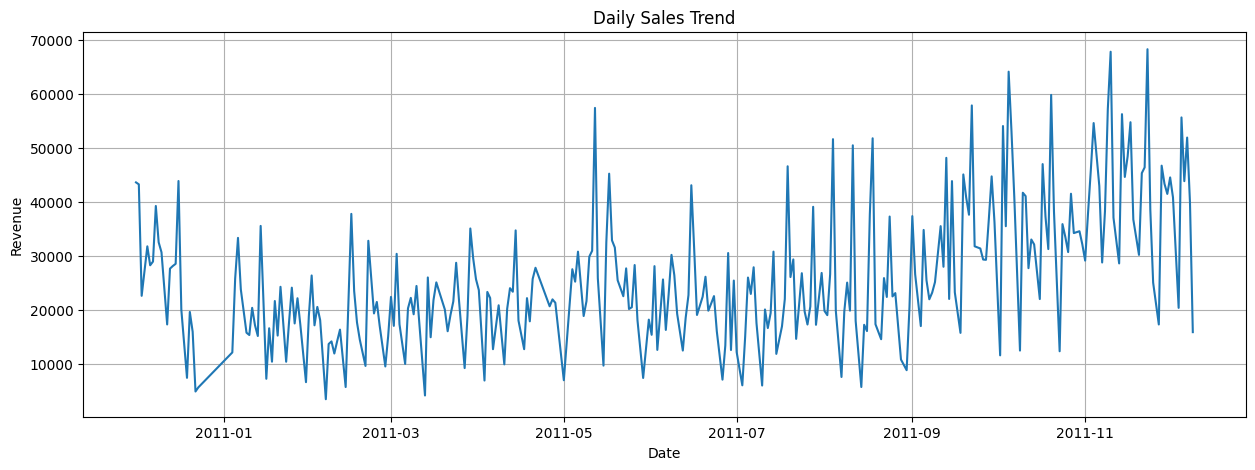

In [56]:
#plot daily sales
plt.figure(figsize=(15, 5))
plt.plot(daily_sales['Date'], daily_sales['Revenue'])
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [57]:
#save

rfm_clean.to_csv('features_rfm.csv', index=False)
product_features.to_csv('features_products.csv', index=False)
daily_sales.to_csv('features_daily_sales.csv', index=False)

print("Feature tables saved to CSV")

Feature tables saved to CSV
